# Fig 2 — Qualitative reconstruction

Qualitative panels comparing **olAE** and **nlscVI** at latent=128 across the three datasets.

- **Tahoe** — UMAPs (true, train/test overlay)
- **PBMC** — UMAPs (true, train/test overlay) + pathway-activity (TNF-α stim, CD14 Mono)
- **LuCA** — UMAPs (true, train/test overlay) + cell-cycle phase

All checkpoints are split01, latent=128.

## 1. Imports & shared helpers

In [1]:
import os
import sys
import re
import glob
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import zarr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import pickle
import warnings
warnings.filterwarnings('ignore')

FIGS_DIR   = '../figs/fig2/'

MODEL_KEYS  = ['olAE', 'nlscVI', 'PCA']
MODEL_LABEL = {'olAE': 'AE', 'nlscVI': 'VAE', 'PCA': 'PCA'}

In [2]:
def build_plot_adata(adata_true, recons, not_train_set, celltype_key='cell_type'):
    adata_true = adata_true.copy()
    adata_true.obs['source'] = 'True'
    adata_true.obs['set'] = np.where(
        adata_true.obs[celltype_key].isin(not_train_set), 'test', 'train'
    )

    pieces = [adata_true]
    for name, a in recons.items():
        a = a[a.obs[celltype_key].isin(not_train_set)].copy()
        a.obs['source'] = name
        a.obs['set'] = 'test'
        a.var_names = adata_true.var_names.copy()
        pieces.append(a)
    return ad.concat(pieces, axis=0, join='inner', index_unique=None)

def compute_umap(plot_adata, random_state=42):
    sc.tl.pca(plot_adata)
    sc.pp.neighbors(plot_adata)
    sc.tl.umap(plot_adata, random_state=random_state)
    return plot_adata

def plot_true_train_test(plot_adata, save_name, size=15):
    a = plot_adata[plot_adata.obs['source'] == 'True'].copy()
    a.obs['set'] = pd.Categorical(a.obs['set'], categories=['train', 'test'], ordered=True)
    sc.pl.umap(
        a, color='set', frameon=False, size=size,
        palette={'train': 'lightgray', 'test': 'tab:blue'},
        na_color='lightgrey', legend_fontsize=7, save=save_name,
    )

def plot_true_celltype(plot_adata, celltype_key, save_name, size=15, legend_loc='right margin'):
    a = plot_adata[plot_adata.obs['source'] == 'True'].copy()
    sc.pl.umap(
        a, color=celltype_key, frameon=False, size=size,
        legend_loc=legend_loc, legend_fontsize=7,
        na_color='lightgrey', save=save_name,
    )

def plot_overlay_train_test(plot_adata, model_name, *,
                            true_test_color='tab:blue',
                            recon_test_color='#DB4444',
                            size=15, save=None, random_state=0):
    keep = (
        ((plot_adata.obs['source'] == 'True') & (plot_adata.obs['set'] == 'test')) |
        ((plot_adata.obs['source'] == model_name) & (plot_adata.obs['set'] == 'test'))
    )
    sub = plot_adata[keep].copy()
    sub.obs['overlay'] = np.where(sub.obs['source'] == 'True',
                                  'True_test', f'{model_name}_test')

    rng = np.random.default_rng(random_state)
    perm = rng.permutation(sub.n_obs)
    sub = sub[perm].copy()

    cats = ['True_test', f'{model_name}_test']
    sub.obs['overlay'] = pd.Categorical(sub.obs['overlay'], categories=cats, ordered=True)
    palette = {'True_test': true_test_color, f'{model_name}_test': recon_test_color}

    sc.pl.umap(
        sub, color='overlay', palette=[palette[c] for c in cats],
        title=f'True_test (blue) vs {model_name}_test (red)',
        frameon=False, size=size, save=save,
    )

## 2a. Tahoe — DEG signal recovery (boxplots, latent=128)

Per-metric horizontal boxplot comparing **AE / VAE / PCA** at latent=128 across 3 splits. Brackets show paired t-test (skipped when n.s.); ↑/↓ in titles indicate metric direction.

In [3]:
from dataclasses import dataclass
from typing import Sequence, Mapping, Optional, Union
from scipy import stats as _stats

@dataclass
class ResultItem:
    dataset: str
    split: str
    source: Union[str, pd.DataFrame]
    model_col: Optional[str] = "Unnamed: 0"
    latent: Optional[str] = None


def _load_one(item: ResultItem) -> pd.DataFrame:
    df = pd.read_csv(item.source) if isinstance(item.source, str) else item.source.copy()
    df["_model"]   = df.index.astype(str) if item.model_col is None else df[item.model_col].astype(str)
    df["_dataset"] = item.dataset
    df["_split"]   = item.split
    if item.latent is not None: df["_latent"] = str(item.latent)
    return df


def combine_results(items, *, models, model_rename=None):
    dfs = []
    for it in items:
        d = _load_one(it)
        if model_rename is not None:
            d["_model"] = d["_model"].map(lambda x: model_rename.get(x, x))
        d = d[d["_model"].isin(models)].copy()
        dfs.append(d)
    big = pd.concat(dfs, axis=0, ignore_index=True)
    big["_model"] = pd.Categorical(big["_model"], categories=list(models), ordered=True)
    return big


def to_long(big_df, *, metric_cols=None):
    meta = [c for c in big_df.columns if c.startswith("_")]
    if metric_cols is None:
        metric_cols = [c for c in big_df.columns if c not in meta]
    long = big_df.melt(id_vars=meta, value_vars=list(metric_cols),
                       var_name="metric", value_name="value")
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    return long


def _stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."


def plot_tahoe_boxplots(long_df, *, metrics, model_labels, models,
                         layout=(2, 2), figsize=(7, 4.6),
                         box_color="#9ec5e8", median_color="#d94b1f",
                         out_svg=None, title_map=None,
                         higher_is_better=None):
    fig, axes = plt.subplots(*layout, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()

    for ax in axes_flat[len(metrics):]:
        ax.axis("off")

    for ax, m in zip(axes_flat[:len(metrics)], metrics):
        d = long_df[long_df["metric"] == m].copy()
        data = [d.loc[d["_model"] == model, "value"].dropna().to_numpy()
                for model in models]

        bp = ax.boxplot(
            data, vert=False, positions=np.arange(len(models)),
            widths=0.55, patch_artist=True, showfliers=False,
            medianprops=dict(linewidth=1.4, color=median_color),
            boxprops=dict(linewidth=0.9, edgecolor="#333"),
            whiskerprops=dict(linewidth=0.9, color="#333"),
            capprops=dict(linewidth=0.9, color="#333"),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(box_color); patch.set_alpha(0.5)

        ax.set_yticks(np.arange(len(models)))
        ax.set_yticklabels([model_labels.get(mod, mod) for mod in models], fontsize=13)
        ax.invert_yaxis()  # AE on top
        ax.grid(True, axis="x", ls="--", alpha=0.3); ax.set_axisbelow(True)
        ax.tick_params(axis="x", labelsize=11)
        for s in ["top", "right"]:
            ax.spines[s].set_visible(False)

        title = (title_map or {}).get(m, m)
        if higher_is_better is not None and m in higher_is_better:
            title = title + (" ↑" if higher_is_better[m] else " ↓")
        ax.set_title(title, fontsize=14, pad=6)

        # Paired-t brackets on the right (skip n.s.)
        xmax_data = max((arr.max() for arr in data if arr.size), default=0.0)
        xmin_data = min((arr.min() for arr in data if arr.size), default=0.0)
        x_span = max(xmax_data - xmin_data, 1e-6)
        x_pad  = x_span * 0.06
        x_anchor = xmax_data + x_pad
        x_step   = x_span * 0.06
        y_step   = 0.18

        pairs = [(i, j) for i in range(len(models)) for j in range(i+1, len(models))]
        for k, (i, j) in enumerate(pairs):
            a, b = data[i], data[j]
            if len(a) < 2 or len(b) < 2 or len(a) != len(b):
                continue
            try:
                _, p = _stats.ttest_rel(a, b)
            except Exception:
                continue
            if not (p < 0.05):     # skip non-significant pairs
                continue
            x_b = x_anchor + k * x_step
            ax.plot([x_b, x_b], [i + y_step, j - y_step], color="0.3", lw=0.8)
            ax.plot([x_b - x_step*0.25, x_b], [i + y_step, i + y_step], color="0.3", lw=0.8)
            ax.plot([x_b - x_step*0.25, x_b], [j - y_step, j - y_step], color="0.3", lw=0.8)
            ax.text(x_b + x_step*0.25, (i + j) / 2, _stars(p),
                    va="center", ha="left", fontsize=14, fontweight="bold", color="0.2")

        ax.set_xlim(left=xmin_data - x_pad,
                    right=x_anchor + len(pairs) * x_step + x_step * 1.2)

    plt.tight_layout()
    if out_svg:
        fig.savefig(out_svg, bbox_inches="tight", format="svg")
    plt.show()

RES_DIR      = "../frozen/figs/results"
MODELS       = ["mlAE", "nlscVI", "PCA"]
MODEL_LABELS = {"mlAE": "AE", "nlscVI": "VAE", "PCA": "PCA"}

items_tahoe = [
    ResultItem(dataset="tahoe", split=s,
               source=f"{RES_DIR}/tahoe_{s}_metrics_summary_latent128.csv",
               model_col="Unnamed: 0", latent="128")
    for s in ["split01", "split02", "split03"]
]
big_tahoe  = combine_results(items_tahoe, models=MODELS)
long_tahoe = to_long(big_tahoe)

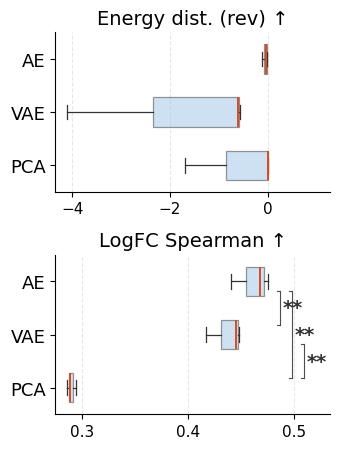

In [4]:
metrics_tahoe = ["rev_distributional_energy_distance",
                 "deg_wilcoxon_pred_mean_genediff_spearman"]
title_map_tahoe = {
    "rev_distributional_energy_distance":       "Energy dist. (rev)",
    "deg_wilcoxon_pred_mean_genediff_spearman": "LogFC Spearman",
}
hib_tahoe = {m: True for m in metrics_tahoe}

plot_tahoe_boxplots(
    long_tahoe, metrics=metrics_tahoe, models=MODELS, model_labels=MODEL_LABELS,
    layout=(2, 1), figsize=(3.5, 4.6),
    title_map=title_map_tahoe, higher_is_better=hib_tahoe,
    out_svg=f"{FIGS_DIR}/tahoe_boxplots_latent128.svg",
)

## 2b. Tahoe — LogFC scatter (CVCL_0320 · Dabrafenib)

True vs Predicted log-fold-change for the top DEGs of CVCL_0320 perturbed with Dabrafenib (vs DMSO_TF control). Three-color scatter (AE / VAE / PCA), with **EGR1** (red) and **AXIN2** (black) highlighted; per-gene zoom-in scatters below.

In [5]:
ptb_adata = ad.read_h5ad('../frozen/tahoe_ptb_data.h5ad')
ref_adata = ad.read_h5ad('../frozen/tahoe_ref_data.h5ad')

with open('../frozen/tahoe_recon_pairs.pkl', 'rb') as f:
    recon_pairs = pickle.load(f)
    f.close()

with open('../frozen/tahoe_gene_names.pkl', 'rb') as f:
    gene_names = pickle.load(f)
    f.close()

In [6]:
from utils import (plot_logfc_overlay_models,
                   build_gene_logfc_df_one_cellline,
                   plot_gene_true_vs_pred_multi_models,
                   list_treated_keys_from_fs,
                   wilcoxon_deg_mask)

LOGFC_MODELS = ["olAE", "nlscVI", "PCA"]
LOGFC_COLORS = {"olAE": "#2171b5", "nlscVI": "#7a0177", "PCA": "#ffbf00"}

cell_line = "CVCL_0320"
drug = "Dabrafenib"
dose = "0_5"
control = "DMSO_TF"
models = LOGFC_MODELS
colors = LOGFC_COLORS

eps = 1.0
alpha = 0.05
min_abs_logfc = 0.2
point_size = 20

max_genes = 16
highlight_genes = ["EGR1", "AXIN2"]
highlight_colors = ["red", "black"]
point_alpha = 0.8
out_path = f"{FIGS_DIR}/tahoe_logfc_dabrafenib.svg"

treat_key = f"{cell_line}-{drug}-{dose}"
ctrl_key  = f"{cell_line}-{control}-0"

for a in (ptb_adata, ref_adata):
    a.var_names = gene_names

deg_mask, deg_table = wilcoxon_deg_mask(
    ptb_adata, ref_adata, gene_names,
    alpha=alpha, min_abs_logfc=min_abs_logfc, eps=eps, max_genes=max_genes
)

highlight_used = []
highlight_set = {g.upper() for g in highlight_genes}
gene_upper = pd.Index(gene_names.astype(str)).str.upper()
highlight_mask = gene_upper.isin(highlight_set)

idx_all = np.where(deg_mask & highlight_mask)[0]
highlight_used = [str(gene_names[i]) for i in idx_all]

title = f"{cell_line} · {drug} perturbed"

Found 16 DEGs (FDR≤0.05, |logFC|≥0.2)


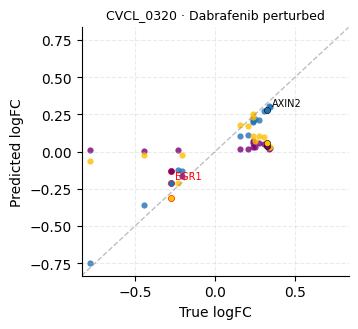

In [7]:
plot_logfc_overlay_models(
    true_treat=ptb_adata,
    true_ctrl=ref_adata,
    recon_pairs=recon_pairs,
    deg_mask=deg_mask,
    gene_names=gene_names,
    highlight_mask=highlight_mask,
    highlight_labels=highlight_used,
    eps=eps,
    colors=colors,
    point_size=point_size,
    point_alpha=point_alpha,
    title=title,
    out_path=out_path,
    annotate_highlights=True,
    highlight_edgecolors=highlight_colors,
)

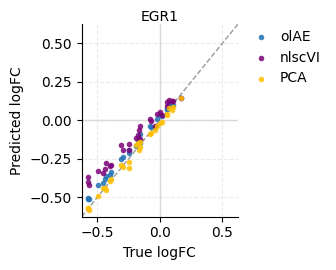

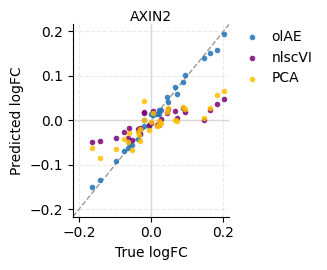

In [8]:
for gene in ["EGR1", "AXIN2"]:
    df_gene = pd.read_csv(f'../frozen/tahoe_df_{gene}.csv')
    
    plot_gene_true_vs_pred_multi_models(
        df_gene, gene=gene,
        models=LOGFC_MODELS,
        model_colors=LOGFC_COLORS,
        figsize=(3.4, 2.8),
        base_alpha=0.85,
        out_path=f"{FIGS_DIR}/tahoe_logfc_{gene.lower()}_zoom.svg",
    )


## 3. Tahoe — UMAPs

In [9]:
tahoe_plot = ad.read_h5ad("../frozen/tahoe_plot.h5ad")

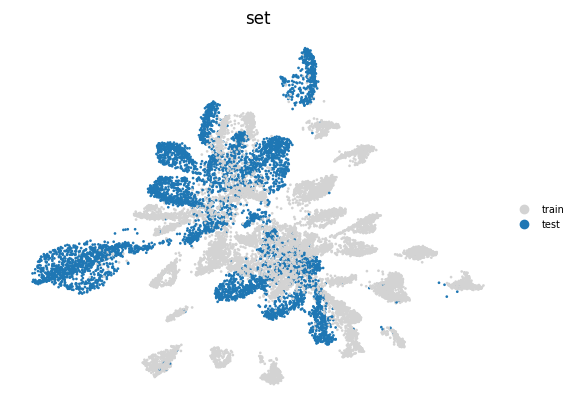

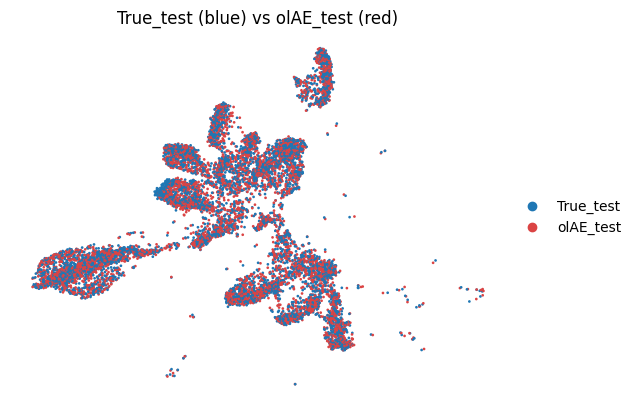

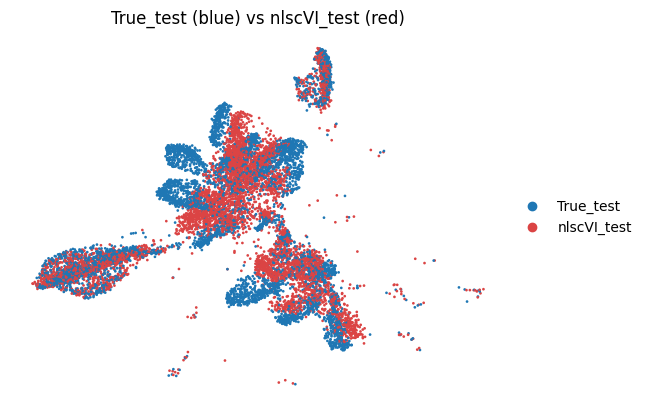

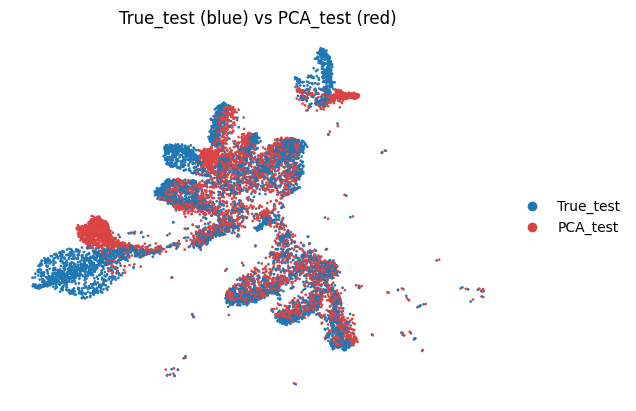

In [10]:
plot_true_train_test(tahoe_plot, save_name='tahoe_true_train_test.svg')

for k in MODEL_KEYS:
    plot_overlay_train_test(tahoe_plot, k, save=f'tahoe_{k}_overlay.svg')

!mv -f ./figures/* ../figs/fig2/
!rm -r ./figures

## 3b. PBMC — DEG signal recovery (boxplots, latent=128)

Per-metric boxplot at latent=128 on the **3b. PBMC** dataset, aggregated across 3 splits. Brackets show paired t-test (skipped when n.s.). Direction arrow appended to each title.

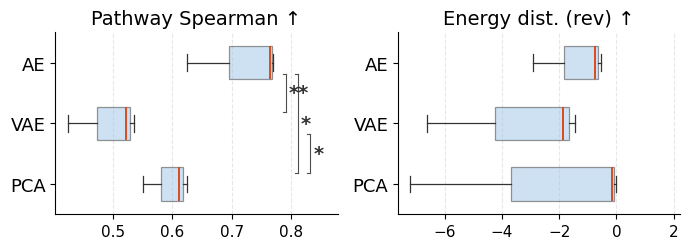

In [11]:
items_pbmc = [
    ResultItem(dataset="pbmc", split=s,
               source=f"{RES_DIR}/pbmc_{s}_metrics_summary_latent128.csv",
               model_col="Unnamed: 0", latent="128")
    for s in ["split01", "split02", "split03"]
]
big_pbmc  = combine_results(items_pbmc, models=MODELS)
long_pbmc = to_long(big_pbmc)

metrics_pbmc    = ['pathway_spearman_average', 'rev_distributional_energy_distance']
title_map_pbmc  = {'pathway_spearman_average': 'Pathway Spearman', 'rev_distributional_energy_distance': 'Energy dist. (rev)'}
hib_pbmc        = {'pathway_spearman_average': True, 'rev_distributional_energy_distance': True}

plot_tahoe_boxplots(
    long_pbmc, metrics=metrics_pbmc, models=MODELS, model_labels=MODEL_LABELS,
    layout=(1, 2), figsize=(7, 2.6),
    title_map=title_map_pbmc, higher_is_better=hib_pbmc,
    out_svg=f"{FIGS_DIR}/pbmc_boxplots_latent128.svg",
)

## 4. PBMC — UMAPs

In [34]:
pbmc_plot = ad.read_h5ad("../frozen/pbmc_plot.h5ad")

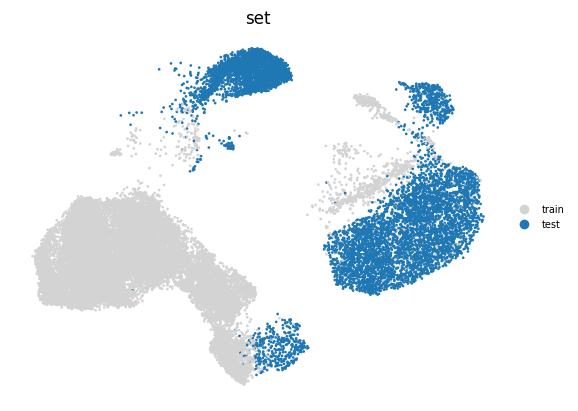

In [36]:
plot_true_train_test(pbmc_plot, save_name='pbmc_true_train_test.svg')

!mv -f ./figures/* ../figs/fig2/
!rm -r ./figures

## 5. PBMC — Pathway activity (PI3K, all test cells)

PI3K PROGENy activity scored on all subsampled test cells. To remove the confound of a varying embedding, **all panels share the True test-cell UMAP coordinates** — each model's per-cell pathway score is placed at its corresponding true cell. Only the score (color) varies between True / olAE / nlscVI / PCA.

In [37]:
def plot_pathway_on_true_coords(plot_adata, pathway, *,
                                sources=('True',) + tuple(MODEL_KEYS),
                                size=15, save_prefix=None):
    true_t = plot_adata[(plot_adata.obs['source'] == 'True') &
                        (plot_adata.obs['set'] == 'test')].copy()

    with open("../frozen/pbmc_plot_dict.pkl", "rb") as f:
        score_cols = pickle.load(f)
        f.close()

    allv = np.concatenate(list(score_cols.values()))
    vmin = float(np.nanpercentile(allv, 2))
    vmax = float(np.nanpercentile(allv, 98))
    obs_key = f'PROGENy_{pathway}'

    for name, vals in score_cols.items():
        a = true_t.copy()
        a.obs[obs_key] = vals
        fig = sc.pl.umap(
            a, color=obs_key, cmap='viridis', vmin=vmin, vmax=vmax,
            size=size, frameon=False,
            title=f'{name} · {pathway} activity (True coords)',
            show=False, return_fig=True,
        )
        if save_prefix:
            fig.savefig(f'{save_prefix}_{name}_{pathway}.svg', bbox_inches='tight')
        plt.show(); plt.close(fig)


test cells: 32664   (sources: ['PCA', 'True', 'nlscVI', 'olAE'])


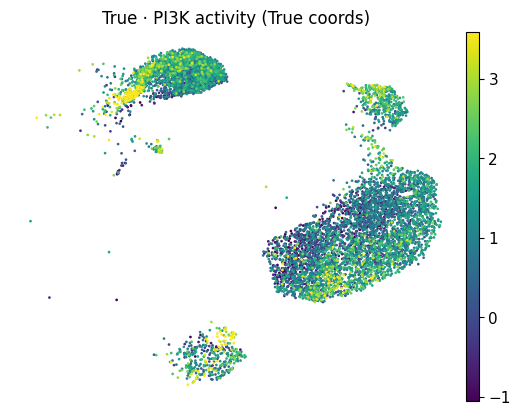

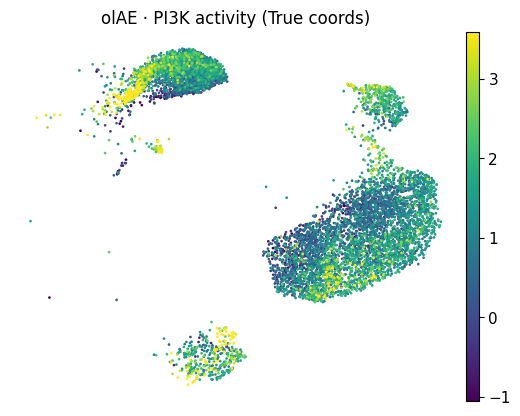

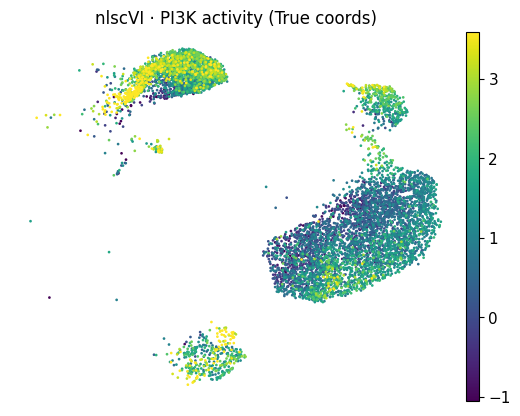

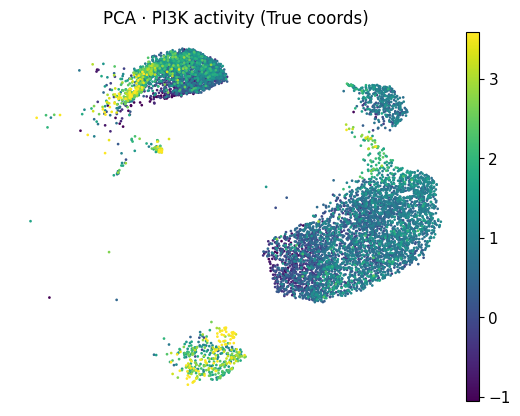

In [38]:
pbmc_test = pbmc_plot[pbmc_plot.obs['set'] == 'test'].copy()
print(f"test cells: {pbmc_test.n_obs}   "
      f"(sources: {sorted(pbmc_test.obs['source'].unique())})")

plot_pathway_on_true_coords(
    pbmc_test, pathway='PI3K',
    save_prefix=f'{FIGS_DIR}/pbmc_pathway',
)

## 5b. LuCA — DEG signal recovery (boxplots, latent=128)

Per-metric boxplot at latent=128 on the **5b. LuCA** dataset, aggregated across 3 splits. Brackets show paired t-test (skipped when n.s.). Direction arrow appended to each title.

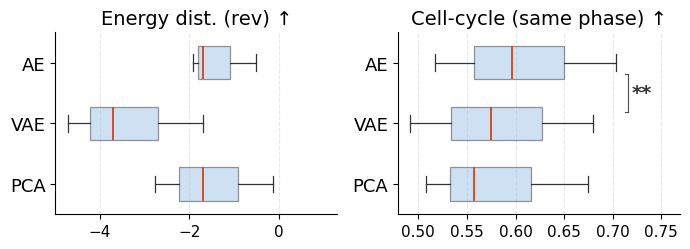

In [16]:
items_luca = [
    ResultItem(dataset="luca", split=s,
               source=f"{RES_DIR}/luca_{s}_metrics_summary_latent128.csv",
               model_col="Unnamed: 0", latent="128")
    for s in ["split01", "split02", "split03"]
]
big_luca  = combine_results(items_luca, models=MODELS)
long_luca = to_long(big_luca)

metrics_luca    = ['rev_distributional_energy_distance', 'cellcycle_proportion_same_phase']
title_map_luca  = {'rev_distributional_energy_distance': 'Energy dist. (rev)', 'cellcycle_proportion_same_phase': 'Cell-cycle (same phase)'}
hib_luca        = {'rev_distributional_energy_distance': True, 'cellcycle_proportion_same_phase': True}

plot_tahoe_boxplots(
    long_luca, metrics=metrics_luca, models=MODELS, model_labels=MODEL_LABELS,
    layout=(1, 2), figsize=(7, 2.6),
    title_map=title_map_luca, higher_is_better=hib_luca,
    out_svg=f"{FIGS_DIR}/luca_boxplots_latent128.svg",
)


## 6. LuCA — UMAPs

In [17]:
luca_in = ad.read_h5ad('../frozen/luca_in_adata.h5ad')

with open('../frozen/luca_recons_umap.pkl', 'rb') as f:
    luca_recons = pickle.load(f)
    f.close()

In [18]:
luca_not_train = {
    'capillary endothelial cell', 'club cell', 'conventional dendritic cell',
    'dendritic cell', 'endothelial cell of lymphatic vessel', 'fibroblast of lung',
    'malignant cell', 'mesothelial cell', 'stromal cell', 'alveolar macrophage',
}
print(f'LuCA sample: {luca_in.n_obs} cells')

luca_plot = build_plot_adata(
    luca_in, luca_recons, luca_not_train, celltype_key='cell_type'
)
compute_umap(luca_plot)

LuCA sample: 22307 cells


AnnData object with n_obs × n_vars = 39992 × 5983
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'EGFR_mutation', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'source', 'set'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_pca',

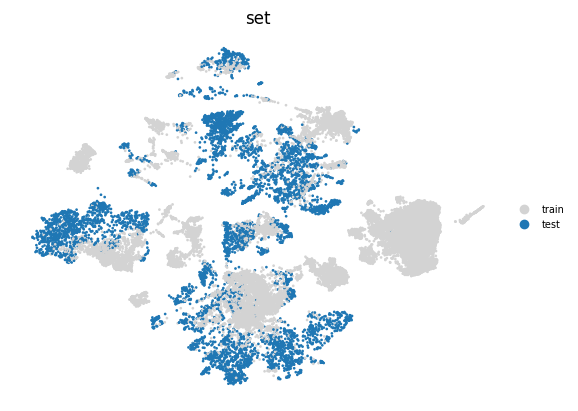

In [19]:
plot_true_train_test(luca_plot, save_name='luca_true_train_test.svg')

!mv -f ./figures/* ../figs/fig2/
!rm -r ./figures

## 7. LuCA — Cell-cycle phase (test cells only)

Score cell-cycle phase (S / G2M / G1) using Regev-lab gene lists, per source.

In [20]:
PHASE_ORDER = ['G1', 'S', 'G2M']
PHASE_COLORS = {'G1': '#2A9D8F', 'S': '#E9C46A', 'G2M': '#8E6BBF'}

def _score_phase(adata, s_genes, g2m_genes, key='phase'):
    if len(s_genes) < 5 or len(g2m_genes) < 5:
        adata.obs[key] = pd.Categorical([np.nan] * adata.n_obs,
                                         categories=PHASE_ORDER, ordered=True)
        return
    sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes, use_raw=False)
    adata.obs[key] = pd.Categorical(adata.obs[key], categories=PHASE_ORDER, ordered=True)

def _subsample_phase(adata, phase_key='phase', target='G1', frac=1.0, seed=42):
    rs = np.random.RandomState(seed)
    phase = adata.obs[phase_key].astype(str).to_numpy()
    keep = np.ones(adata.n_obs, dtype=bool)
    idx = np.where(phase == target)[0]
    if idx.size > 0:
        n_keep = max(1, int(np.floor(frac * idx.size)))
        keep_idx = rs.choice(idx, size=n_keep, replace=False)
        keep[:] = False; keep[keep_idx] = True; keep[phase != target] = True
    return adata[keep].copy()

def plot_cellcycle_test(plot_adata, *, s_genes, g2m_genes,
                       sources=('True',) + tuple(MODEL_KEYS),
                       size=15, g1_frac=1.0, save_prefix=None):
    palette = [PHASE_COLORS[p] for p in PHASE_ORDER]
    for name in sources:
        a = plot_adata[
            (plot_adata.obs['source'] == name)
            & (plot_adata.obs['set'] == 'test')
        ].copy()
        if a.n_obs == 0:
            print(f'[skip] {name}: no test cells'); continue
        _score_phase(a, s_genes, g2m_genes)
        a_plot = _subsample_phase(a, frac=g1_frac) if g1_frac < 1.0 else a
        fig = sc.pl.umap(
            a_plot, color='phase', palette=palette, size=size, frameon=False,
            title=f'{name} · cell cycle (test)', show=False, return_fig=True,
        )
        if save_prefix:
            fig.savefig(f'{save_prefix}_{name}_cellcycle.svg', bbox_inches='tight')
        plt.show(); plt.close(fig)

Cell-cycle genes — S: 18 | G2M: 37


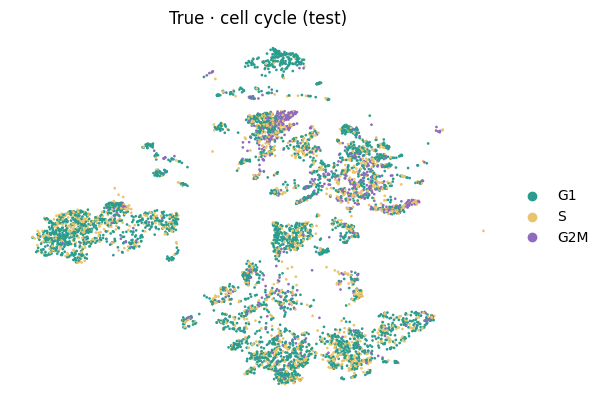

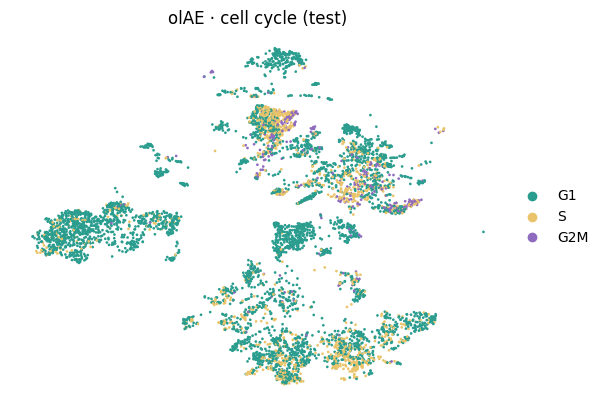

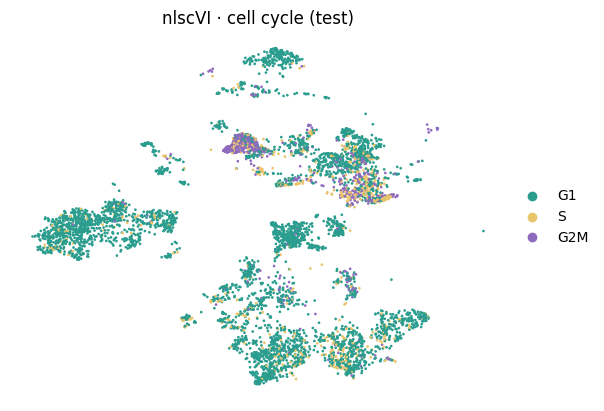

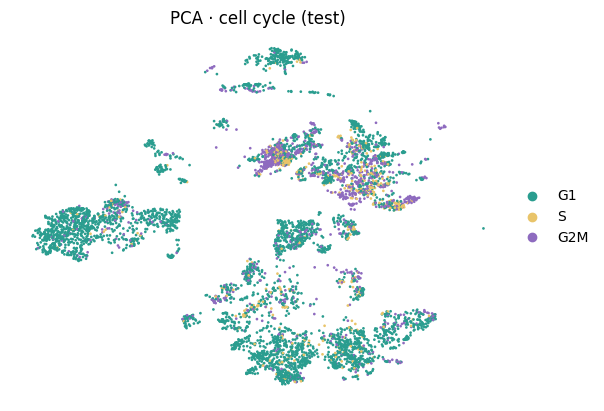

In [21]:
_cc_path = '../frozen/regev_lab_cell_cycle_genes.txt'
with open(_cc_path) as f:
    _cc_genes = [x.strip() for x in f.readlines()]
_s_genes, _g2m_genes = _cc_genes[:43], _cc_genes[43:]

luca_plot.var_names = luca_in.var['feature_name'].tolist()
luca_plot.var.index = luca_in.var['feature_name'].tolist()

_keep = sc.pp.filter_genes(luca_in, min_cells=30, inplace=False)[0]
_expressed = set(luca_in.var['feature_name'].to_numpy()[_keep])
_s_use   = [g for g in _s_genes   if g in _expressed]
_g2m_use = [g for g in _g2m_genes if g in _expressed]
print(f'Cell-cycle genes — S: {len(_s_use)} | G2M: {len(_g2m_use)}')

plot_cellcycle_test(
    luca_plot, s_genes=_s_use, g2m_genes=_g2m_use,
    g1_frac=1.0,
    save_prefix=f'{FIGS_DIR}/luca_cellcycle',
)

# Fig 2 — Summary panel (rank-percentile scores)

Generates the model-comparison summary panel: overall rank-percentile dot + CI per
(model family × library-size mode), with sub-score markers (Statistical, Biological).

Includes **cytokine** as a Biological metric.

**Cytokine availability** (raw results dirs):
- `pbmc`: 120/165 models — fully meaningful
- `luca`: 205/221 models — fully meaningful
- `tahoe`: 19/156 models — drugs aren't cytokines, most rows have `n_common_cytokines=0`
- `hlca`: 0/2 — not used

**Strategy**: cytokine is included in `BIO_METRICS`. Per dataset×split, columns missing or all-NaN are skipped automatically. For tahoe the cytokine column will contribute very little (mostly NaN); for pbmc/luca it adds a real signal.

**Outputs**:
1. `panel_combined_latent{N}.svg` — aggregated across pbmc + luca + tahoe at one latent
2. `panel_{dataset}_latent{N}.svg` — one per (dataset, latent) for QC / per-dataset story

## 1. Model mapping, palettes, metrics

In [22]:
DATASETS = ["pbmc", "luca", "tahoe"]
LATENTS = [10, 32, 128, 512, 2048]
SPLITS = ["split01", "split02", "split03"]

plt.rcParams.update({
    "font.size": 11, "axes.labelsize": 12, "axes.titlesize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.fontsize": 10, "legend.title_fontsize": 10,
})

MODEL_MAP = {
    "AE":      ("AE",   "none",     "AE"),
    "mlAE":    ("AE",   "modeled",  "AE"),
    "olAE":    ("AE",   "observed", "AE"),
    "nlscVI":  ("scVI", "none",     "scVI"),
    "mlscVI":  ("scVI", "modeled",  "scVI"),
    "scVI":    ("scVI", "observed", "scVI"),
    "PCA":     ("PCA",  "none",     "PCA"),
}

mode_icon  = {"none": "●", "modeled": "▲", "observed": "◆"}
mode_order = ["none", "modeled", "observed"]

ae_palette   = ["#08306b", "#2171b5", "#6baed6"]   # none / modeled / observed
scvi_palette = ["#49006a", "#ae017e", "#f768a1"]
pca_color    = "#ffbf00"

def color_for(base, mode):
    if base == "AE":   return ae_palette[mode_order.index(mode)]
    if base == "scVI": return scvi_palette[mode_order.index(mode)]
    if base == "PCA":  return pca_color
    return "grey"

PLOT_ROWS = [
    ("AE",   "none"), ("AE",   "modeled"), ("AE",   "observed"),
    ("scVI", "none"), ("scVI", "modeled"), ("scVI", "observed"),
    ("PCA",  "none"),
]

DIST_METRICS = [
    "rev_distributional_mse",
    "distributional_r2_score",
    "rev_distributional_energy_distance",
]

BIO_METRICS = [
    "pathway_spearman_average",
    "coexpression_spearman_average",
    "cellcycle_proportion_same_phase",
    "deg_wilcoxon_pred_deg_dice_100",
    "deg_wilcoxon_pred_mean_genediff_spearman",
    "cytokine_spearman_average",   
]

## 2. Helpers

In [23]:
def parse_dataset_split_latent(path):
    fname = os.path.basename(path)
    m = re.match(r"(.+?)_(split\d{2})_metrics_summary_latent(\d+)\.csv$", fname)
    if m:
        return m.group(1), m.group(2), int(m.group(3))
    return None, None, None

def read_one_csv(path):
    df = pd.read_csv(path)
    if "model" not in df.columns:
        df = df.rename(columns={df.columns[0]: "model"})
    for c in df.columns:
        if c != "model":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def rank_percentile(series):
    """Paper formula: rp = (M - rank) / (M - 1), where rank 1 = best.

    Caller must orient `s` so that higher value = better (negate
    lower-is-better metrics upstream — see compute_scores_per_replicate).
    Range = [0, 1]; best method gets 1.0, worst gets 0.0.
    """
    series = series.astype(float)
    valid = series.dropna()
    if valid.nunique() <= 1 or len(valid) < 2:
        return pd.Series(np.nan, index=series.index)
    M = len(valid)
    ranks = series.rank(method="average", ascending=False)
    return (M - ranks) / (M - 1)


def _rp_paper(vals, higher_is_better):
    """Paper rank-percentile applied directly to one metric column.

    Used by the funky-heatmap cells where direction is handled per column.
    higher_is_better=True  → best is highest value
    higher_is_better=False → best is lowest value (rank 1 = lowest)
    """
    vals = pd.Series(vals).astype(float)
    M = vals.notna().sum()
    if M < 2 or vals.dropna().nunique() <= 1:
        return pd.Series(np.nan, index=vals.index)
    ranks = vals.rank(method="average", ascending=(not higher_is_better))
    return (M - ranks) / (M - 1)

def bootstrap_ci(values, n_boot=4000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    if len(values) == 1:
        v = float(values[0]); return v, v, v
    boots = np.array([rng.choice(values, size=len(values), replace=True).mean()
                      for _ in range(n_boot)])
    return float(values.mean()), float(np.quantile(boots, alpha/2)), float(np.quantile(boots, 1 - alpha/2))

def load_csvs(paths):
    """Load and concatenate one or more metric-summary CSVs."""
    rows = []
    for p in paths:
        ds, sp, lat = parse_dataset_split_latent(p)
        if ds is None:
            continue
        df = read_one_csv(p)
        df["dataset"], df["split"], df["latent"] = ds, sp, lat
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    all_df = pd.concat(rows, ignore_index=True)
    # Drop unmapped models
    unknown = sorted(set(all_df["model"]) - set(MODEL_MAP))
    if unknown:
        print(f"[warn] dropping unmapped models: {unknown}")
    all_df = all_df[all_df["model"].isin(MODEL_MAP)].copy()
    all_df[["base", "lib_mode", "family"]] = all_df["model"].apply(lambda x: pd.Series(MODEL_MAP[x]))
    return all_df

def compute_scores(all_df):
    """Per (dataset, split) compute rank-percentile scores; per metric col, NaN/missing skipped."""
    records = []
    for (ds, sp), g in all_df.groupby(["dataset", "split"], sort=False):
        g = g.set_index("model")
        dist_cols = [c for c in DIST_METRICS if c in g.columns and g[c].notna().sum() > 1]
        bio_cols  = [c for c in BIO_METRICS  if c in g.columns and g[c].notna().sum() > 1]
        dist = pd.concat([rank_percentile(g[c]) for c in dist_cols], axis=1).mean(axis=1) if dist_cols else pd.Series(np.nan, index=g.index)
        bio  = pd.concat([rank_percentile(g[c]) for c in bio_cols],  axis=1).mean(axis=1) if bio_cols  else pd.Series(np.nan, index=g.index)
        out = pd.DataFrame({
            "dataset": ds, "split": sp, "model": g.index,
            "score_distributional": dist.values,
            "score_biological": bio.values,
            "score_overall": (0.5 * (dist + bio)).values,
            "n_dist_metrics": len(dist_cols),
            "n_bio_metrics":  len(bio_cols),
        })
        out[["base", "lib_mode", "family"]] = out["model"].apply(lambda x: pd.Series(MODEL_MAP[x]))
        records.append(out)
    return pd.concat(records, ignore_index=True)

def aggregate_ci(score_df):
    rows = []
    for (base, mode), g in score_df.groupby(["base", "lib_mode"], sort=False):
        for s in ["score_overall", "score_distributional", "score_biological"]:
            mu, lo, hi = bootstrap_ci(g[s].to_numpy())
            rows.append({"base": base, "lib_mode": mode, "score": s,
                         "mean": mu, "lo": lo, "hi": hi})
    return pd.DataFrame(rows)

## 3. Plotting

In [24]:
def _draw_summary_on_ax(ax, score_df, agg_df, *, xlim=(0.1, 1.0), show_ci=True,
                        show_yticks=True, marker_dist="D", marker_bio="v",
                        y_sub=0.24, ms_sub=5.5, mew_sub=0.9):
    """Draw one rank-percentile summary panel onto a given Axes.

    show_ci=True  → overall point shown as mean ± bootstrap CI error bar
    show_ci=False → overall point shown as a plain dot (use for n<10 replicates)
    """
    ypos = np.arange(len(PLOT_ROWS)).astype(float)
    for i, extra in {2: 0.35, 5: 0.35}.items():
        ypos[i+1:] += extra

    # 1) replicate dots (overall only)
    rng = np.random.default_rng(0)
    for i, (base, mode) in enumerate(PLOT_ROWS):
        rep = score_df[(score_df["base"] == base) & (score_df["lib_mode"] == mode)]
        col = color_for(base, mode)
        xs = rep["score_overall"].dropna().to_numpy()
        if len(xs) == 0: continue
        jit = rng.normal(0, 0.015, size=len(xs))
        ax.scatter(xs, np.full_like(xs, ypos[i]) + jit, s=22, color=col,
                   alpha=0.28, linewidths=0, zorder=1)

    # 2) overall mean (± CI optional) + dist/bio sub-markers
    for i, (base, mode) in enumerate(PLOT_ROWS):
        col = color_for(base, mode)
        sel = lambda s: agg_df[(agg_df["base"] == base) &
                               (agg_df["lib_mode"] == mode) &
                               (agg_df["score"] == s)]
        ro = sel("score_overall")
        if not ro.empty and not np.isnan(ro["mean"].iloc[0]):
            mu = float(ro["mean"].iloc[0])
            if show_ci:
                lo = float(ro["lo"].iloc[0]); hi = float(ro["hi"].iloc[0])
                ax.errorbar(mu, ypos[i], xerr=[[mu-lo], [hi-mu]],
                            fmt="o", ms=6, color=col, mec=col, mew=0.6,
                            elinewidth=2, capsize=3, capthick=1.5, zorder=6)
            else:
                ax.plot(mu, ypos[i], "o", ms=7, color=col, mec=col, mew=0.6, zorder=6)
        rd = sel("score_distributional")
        if not rd.empty and not np.isnan(rd["mean"].iloc[0]):
            ax.plot(float(rd["mean"].iloc[0]), ypos[i] + y_sub,
                    marker=marker_dist, ms=ms_sub, mfc="white", mec=col,
                    mew=mew_sub, linestyle="None", alpha=0.95, zorder=7)
        rb = sel("score_biological")
        if not rb.empty and not np.isnan(rb["mean"].iloc[0]):
            ax.plot(float(rb["mean"].iloc[0]), ypos[i] + y_sub,
                    marker=marker_bio, ms=ms_sub, mfc="white", mec=col,
                    mew=mew_sub, linestyle="None", alpha=0.95, zorder=7)

    ax.set_yticks(ypos)
    if show_yticks:
        ax.set_yticklabels([f"{mode_icon.get(m, '')} " for _, m in PLOT_ROWS])
    ax.invert_yaxis()
    ax.set_xlim(*xlim)
    ax.xaxis.grid(True, linestyle="--", alpha=0.35); ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    sep_kw = dict(color="0.7", linestyle="--", linewidth=0.8, alpha=0.35, zorder=0)
    for i in [2, 5]:
        ax.axhline(0.5 * (ypos[i] + ypos[i+1]), **sep_kw)


def plot_summary_panel(score_df, agg_df, title=None, out_svg=None,
                       xlim=(0.0, 1.0), show_ci=True):
    """Single-panel summary plot (legends on the right)."""
    fig, ax = plt.subplots(figsize=(7.2, 3))
    _draw_summary_on_ax(ax, score_df, agg_df, xlim=xlim, show_ci=show_ci, show_yticks=True)
    ax.set_xlabel("Rank-percentile score")
    if title:
        ax.set_title(title, loc="left", fontsize=11)

    fig.subplots_adjust(right=0.72)
    overall_label = "Overall (mean ± CI)" if show_ci else "Overall (mean)"
    score_h = [
        Line2D([0],[0], marker="o", color="black", linestyle="None", ms=8, label=overall_label),
        Line2D([0],[0], marker="D", color="black", linestyle="None", mfc="white", mew=1.0, ms=6, label="Statistical (mean)"),
        Line2D([0],[0], marker="v", color="black", linestyle="None", mfc="white", mew=1.0, ms=6, label="Biological (mean)"),
    ]
    icon_h = [Patch(facecolor="none", edgecolor="none", label=f"{mode_icon[m]} {m}") for m in mode_order]
    family_h = [
        Patch(facecolor=ae_palette[0],   edgecolor="none", label="AE family"),
        Patch(facecolor=scvi_palette[0], edgecolor="none", label="scVI family"),
        Patch(facecolor=pca_color,       edgecolor="none", label="PCA"),
    ]
    l1 = ax.legend(handles=score_h,  title="Score",             loc="upper left", bbox_to_anchor=(1.01, 1.00), frameon=False)
    l2 = ax.legend(handles=icon_h,   title="Library size mode", loc="upper left", bbox_to_anchor=(1.01, 0.68), frameon=False)
    l3 = ax.legend(handles=family_h, title="Model family",      loc="upper left", bbox_to_anchor=(1.01, 0.40), frameon=False)
    ax.add_artist(l1); ax.add_artist(l2); ax.add_artist(l3)
    plt.tight_layout(rect=[0, 0, 0.72, 1])
    if out_svg:
        fig.savefig(out_svg, format="svg", bbox_inches="tight",
                    bbox_extra_artists=[l1, l2, l3])
        print(f"  → saved: {out_svg}")
    plt.show()
    return fig


def plot_summary_grid(out_svg=None,
                      datasets=DATASETS, latents=LATENTS,
                      ds_labels=None, xlim=(0.0, 1.0)):
    """Grid layout: rows=latents, columns=datasets. Per-dataset panels (n=3) have NO CI."""
    if ds_labels is None:
        ds_labels = {"tahoe": "Tahoe-100M", "pbmc": "PBMC-10M", "luca": "LuCA"}

    n_rows, n_cols = len(latents), len(datasets)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.6 * n_cols, 1.85 * n_rows + 0.8),
                             sharex=True, sharey=True)
    if n_rows == 1: axes = np.array([axes])
    if n_cols == 1: axes = axes.reshape(-1, 1)

    for r, latent in enumerate(latents):
        for c, ds in enumerate(datasets):
            ax = axes[r, c]
            paths = [os.path.join(RES_DIR, f"{ds}_{s}_metrics_summary_latent{latent}.csv")
                     for s in SPLITS
                     if os.path.exists(os.path.join(RES_DIR, f"{ds}_{s}_metrics_summary_latent{latent}.csv"))]
            if not paths:
                ax.text(0.5, 0.5, "no data", ha="center", va="center",
                        transform=ax.transAxes, color="grey")
                ax.set_xticks([]); ax.set_yticks([])
                continue
            all_df = load_csvs(paths)
            score_df = compute_scores(all_df)
            agg_df   = aggregate_ci(score_df)
            _draw_summary_on_ax(ax, score_df, agg_df,
                                xlim=xlim, show_ci=False,
                                show_yticks=(c == 0))
            if r == n_rows - 1:
                ax.set_xlabel("Rank-percentile score")
            if r == 0:
                ax.set_title(ds_labels.get(ds, ds), fontsize=14)
            if c == 0:
                ypos_local = np.arange(len(PLOT_ROWS)).astype(float)
                for i, extra in {2: 0.35, 5: 0.35}.items():
                    ypos_local[i+1:] += extra
                ax.set_yticks(ypos_local)
                ax.set_yticklabels([mode_icon[m] for _, m in PLOT_ROWS], fontsize=14)
                family_groups = [("AE", [0, 1, 2]), ("VAE", [3, 4, 5]), ("PCA", [6])]
                for fam, idxs in family_groups:
                    y_center = float(np.mean([ypos_local[i] for i in idxs]))
                    ax.text(-0.18, y_center, fam, ha="right", va="center",
                            fontsize=14, fontweight="bold",
                            transform=ax.get_yaxis_transform(), clip_on=False)

        axes[r, 0].annotate(f"{latent}", xy=(-0.30, 0.5), xycoords="axes fraction",
                            ha="center", va="center", fontsize=14, rotation=90,
                            fontweight="bold")

    score_h = [
        Line2D([0],[0], marker="o", color="black", linestyle="None", ms=8, label="Overall (mean)"),
        Line2D([0],[0], marker="D", color="black", linestyle="None", mfc="white", mew=1.0, ms=6, label="Statistical (mean)"),
        Line2D([0],[0], marker="v", color="black", linestyle="None", mfc="white", mew=1.0, ms=6, label="Biological (mean)"),
    ]
    icon_h = [Patch(facecolor="none", edgecolor="none", label=f"{mode_icon[m]} {m}") for m in mode_order]
    leg1 = fig.legend(handles=score_h,  title="Score",
                      loc="lower center", bbox_to_anchor=(0.65, -0.04),
                      ncol=3, frameon=False, title_fontsize=14, fontsize=14)
    leg2 = fig.legend(handles=icon_h,   title="Library size mode",
                      loc="lower center", bbox_to_anchor=(0.25, -0.04),
                      ncol=3, frameon=False, title_fontsize=14, fontsize=14)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.10)
    if out_svg:
        fig.savefig(out_svg, format="svg", bbox_inches="tight",
                    bbox_extra_artists=[leg1, leg2])
        print(f"  → saved: {out_svg}")
    plt.show()
    return fig

## 4. Headline: combined latent-128

Standalone panel — same data as cell 12's latent=128 entry, but rendered alone for embedding in `fig2.ipynb`. CI removed (n=9 points is too small for a meaningful bootstrap interval).

latent=128: 9 CSVs
  → saved: ../figs/fig2/panel_combined_latent128.svg


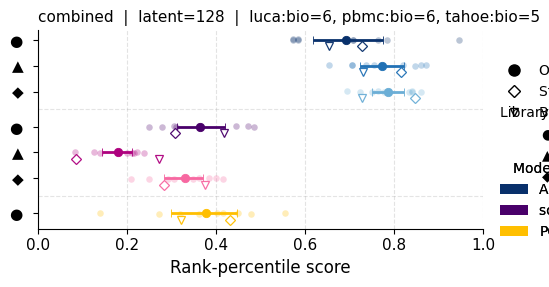

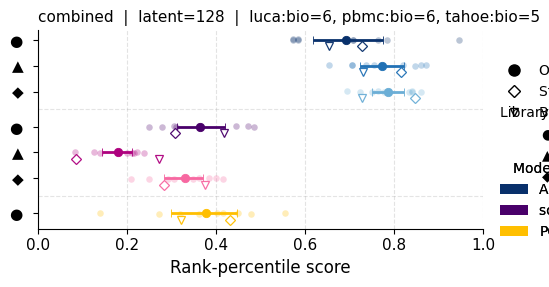

In [25]:
latent = 128
paths = [os.path.join(RES_DIR, f"{ds}_{s}_metrics_summary_latent{latent}.csv")
         for ds in DATASETS for s in SPLITS
         if os.path.exists(os.path.join(RES_DIR, f"{ds}_{s}_metrics_summary_latent{latent}.csv"))]
print(f"latent={latent}: {len(paths)} CSVs")

all_df_128   = load_csvs(paths)
score_df_128 = compute_scores(all_df_128)
agg_df_128   = aggregate_ci(score_df_128)

cov = score_df_128.groupby("dataset")["n_bio_metrics"].max().to_dict()
cov_str = ", ".join(f"{d}:bio={n}" for d, n in cov.items())
title = f"combined  |  latent={latent}  |  {cov_str}"
out_svg = os.path.join(FIGS_DIR, f"panel_combined_latent{latent}.svg")
plot_summary_panel(score_df_128, agg_df_128, title=title, out_svg=out_svg)

## 5. Per-dataset × per-latent grid

5×3 layout: rows = latent (10/32/128/512/2048), columns = datasets (Tahoe/PBMC/LuCA). Per-dataset panels use n=3 splits → CI dropped (mean only).

  → saved: ../figs/fig2/panel_grid_dataset_x_latent.svg


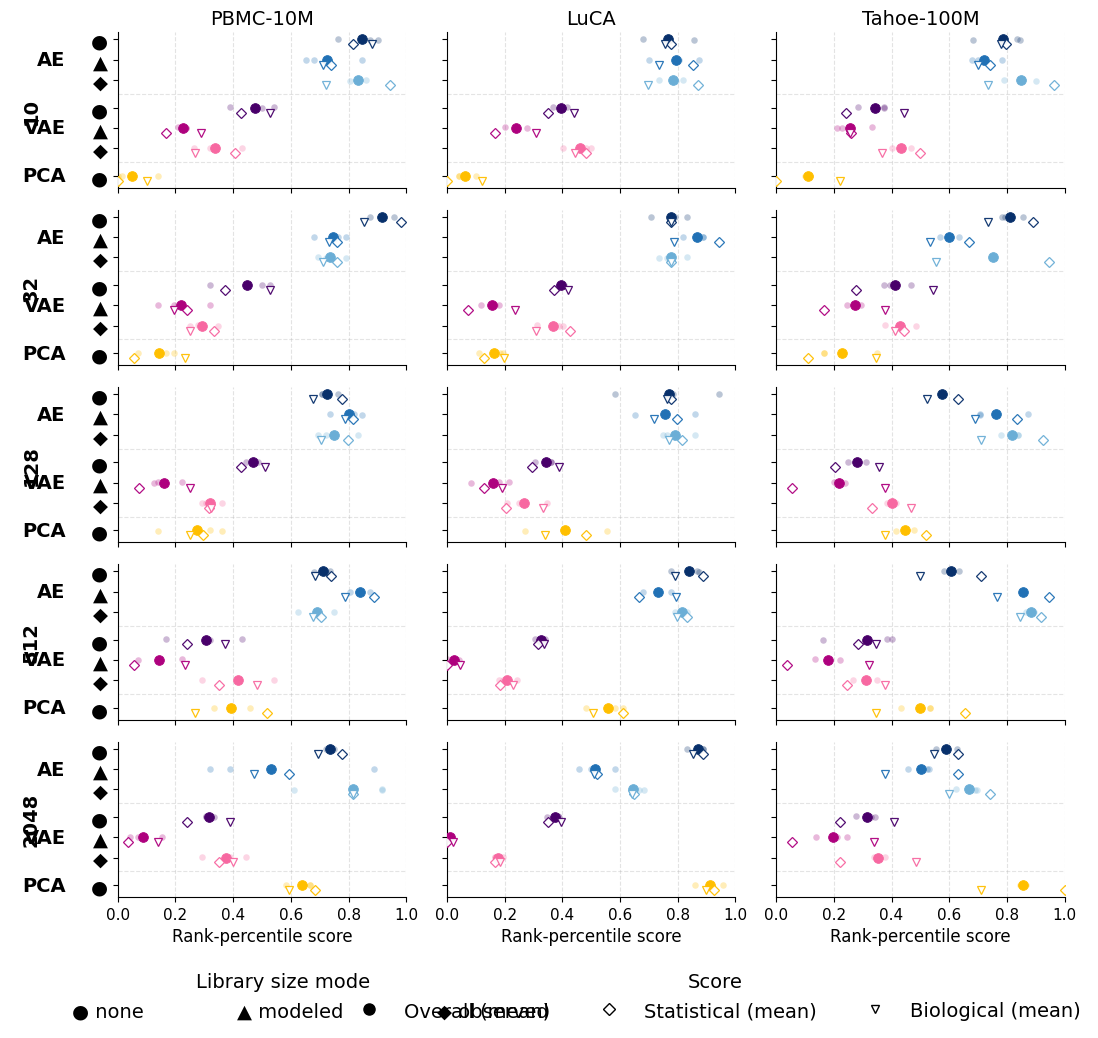

In [26]:
_ = plot_summary_grid(out_svg=os.path.join(FIGS_DIR, "panel_grid_dataset_x_latent.svg"))

# Fig 2 — Metric scaling

Two views (no rank-aggregation, no bootstrap CI — just per-metric values):

1. **Latent-size scaling** — for each metric, value vs latent size, **using split01 only** (each split is a different OOD test set; averaging across them is not meaningful). One panel per dataset, lines per model class.
2. **OOD (split) robustness** — for each metric, value vs split (split01/02/03), one panel per (dataset × latent), lines per model class. Shows how each model degrades on different held-out test sets.

Inputs: pre-processed CSVs at `notebooks/figs/results/{dataset}_{split}_metrics_summary_latent{N}.csv`.
Cytokine columns are present for pbmc/luca, missing for tahoe (skipped automatically).

Outputs: SVGs in `notebooks/figs/fig2/`:
- `scaling_latent_{metric}.svg`
- `scaling_split_{metric}.svg`

In [27]:
MODEL_MAP = {
    "AE":      ("AE",   "none",     "AE"),
    "mlAE":    ("AE",   "modeled",  "AE"),
    "olAE":    ("AE",   "observed", "AE"),
    "nlscVI":  ("scVI", "none",     "scVI"),
    "mlscVI":  ("scVI", "modeled",  "scVI"),
    "scVI":    ("scVI", "observed", "scVI"),
    "PCA":     ("PCA",  "none",     "PCA"),
}
MODEL_ORDER = ["PCA", "olAE", "nlscVI"]

DISPLAY_NAMES = {"olAE": "AE", "nlscVI": "VAE"}

MODEL_COLOR = {
    "PCA":    "#ffbf00",
    "AE":     "#2171b5",
    "olAE":   "#2171b5",
    "mlAE":   "#2171b5",  # same as AE per user request
    "scVI":   "#ae017e",
    "nlscVI": "#ae017e",  # VAE color
    "mlscVI": "#f768a1",
}
MODEL_MARKER = {
    "PCA": "D", "AE": "o", "olAE": "s", "mlAE": "^",
    "scVI": "v", "nlscVI": "P", "mlscVI": "X",
}

METRICS = [
    ("rev_distributional_energy_distance",       "Energy dist (rev)",       True),
    ("deg_wilcoxon_pred_mean_genediff_spearman", "LogFC Spearman",      True),
]

## 1. Loaders — long-format dataframe

In [28]:
def parse_filename(path):
    m = re.match(r"(.+?)_(split\d{2})_metrics_summary_latent(\d+)\.csv$", os.path.basename(path))
    return (m.group(1), m.group(2), int(m.group(3))) if m else (None, None, None)

def load_long():
    """Return long-format df: dataset, split, latent, model, metric, value."""
    rows = []
    for path in sorted(glob.glob(f"{RES_DIR}/*_split??_metrics_summary_latent*.csv")):
        ds, sp, lat = parse_filename(path)
        if ds is None or ds not in DATASETS or lat not in LATENTS or sp not in SPLITS:
            continue
        df = pd.read_csv(path)
        if "model" not in df.columns:
            df = df.rename(columns={df.columns[0]: "model"})
        df = df[df["model"].isin(MODEL_MAP)].copy()
        for _, r in df.iterrows():
            for col, _, _ in METRICS:
                if col not in df.columns:
                    continue
                val = pd.to_numeric(pd.Series([r[col]]), errors="coerce").iloc[0]
                rows.append({
                    "dataset": ds, "split": sp, "latent": lat,
                    "model": r["model"], "metric": col, "value": val,
                })
    long = pd.DataFrame(rows)
    print(f"Loaded long table: {len(long):,} rows, "
          f"datasets={long['dataset'].nunique()}, latents={long['latent'].nunique()}, "
          f"splits={long['split'].nunique()}, models={long['model'].nunique()}, "
          f"metrics={long['metric'].nunique()}")
    return long

long_df = load_long()

Loaded long table: 630 rows, datasets=3, latents=5, splits=3, models=7, metrics=2


## 2. Plot 1 — scaling with latent size

For each metric: one figure with `1 × len(DATASETS)` panels. X = latent size (log), Y = metric value.

Uses **split01 only** (averaging over splits would mix different OOD test sets — not a meaningful aggregate). One value per (dataset, latent, model).

  → ../figs/fig2/scaling_latent_rev_distributional_energy_distance.svg


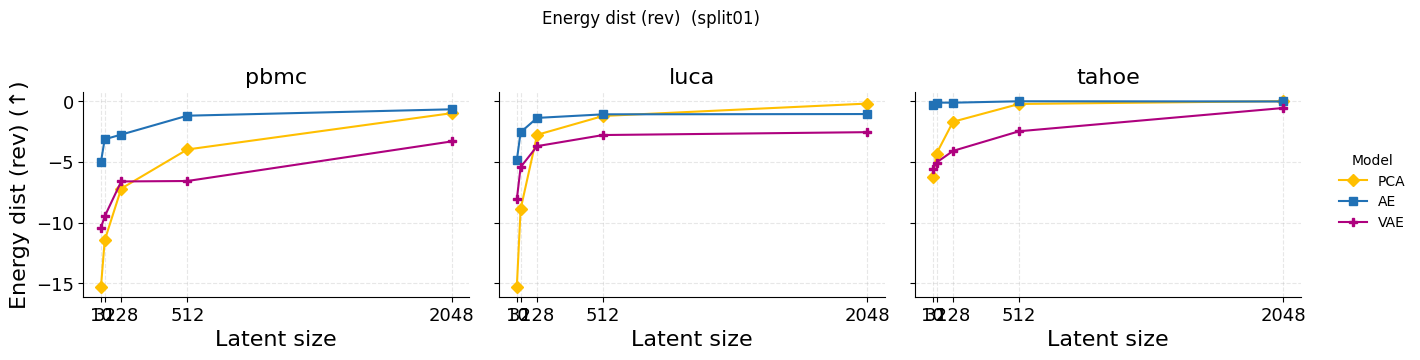

  → ../figs/fig2/scaling_latent_deg_wilcoxon_pred_mean_genediff_spearman.svg


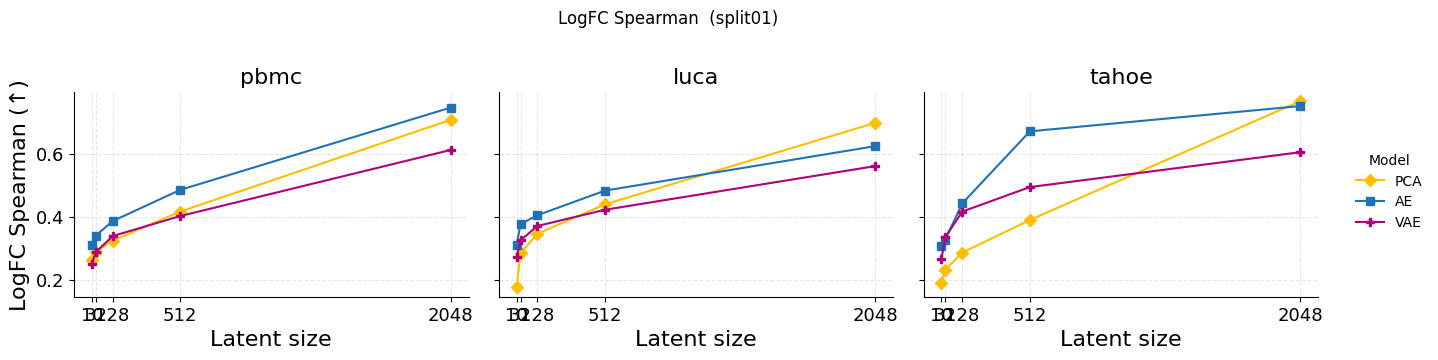

In [29]:
def plot_scaling_latent(long_df, metric_col, metric_label, higher_is_better,
                        out_svg=None, ref_split="split01"):
    """Use only ref_split (default split01) — averaging across splits doesn't make sense
    because each split is a different OOD test set. One value per (dataset, latent, model)."""
    sub = long_df[(long_df["metric"] == metric_col) &
                  (long_df["split"] == ref_split)].copy()
    no_data = sub["value"].notna().sum() == 0

    fig, axes = plt.subplots(1, len(DATASETS), figsize=(4.5 * len(DATASETS), 3.5), sharey=True)
    if len(DATASETS) == 1:
        axes = [axes]
    if no_data:
        for ax in axes:
            ax.text(0.5, 0.5, "Pending\n(running)", ha="center", va="center",
                    transform=ax.transAxes, fontsize=11, color="grey", style="italic")
            ax.set_xscale("log", base=2)
            ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
            ax.set_xticks(LATENTS); ax.set_xlabel("Latent size", fontsize=16)
            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
        axes[0].set_ylabel(metric_label + (" (↑)" if higher_is_better else " (↓)"))
        fig.suptitle(metric_label + f" — placeholder ({ref_split})", y=1.02,
                     fontsize=12, color="grey")
        plt.tight_layout()
        if out_svg:
            fig.savefig(out_svg, format="svg", bbox_inches="tight")
            print(f"  → {out_svg} (placeholder)")
        plt.show()
        return fig

    for ax, ds in zip(axes, DATASETS):
        d = sub[sub["dataset"] == ds]
        for model in MODEL_ORDER:
            md = d[d["model"] == model].sort_values("latent")
            if md.empty:
                continue
            color = MODEL_COLOR[model]; marker = MODEL_MARKER[model]
            ax.plot(md["latent"], md["value"],
                    marker=marker, ms=6, lw=1.5, color=color, label=DISPLAY_NAMES.get(model, model), zorder=3)
        # ax.set_xscale("log", base=2)
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.set_xticks(LATENTS)
        ax.set_xlabel("Latent size", fontsize=16)
        ax.set_title(ds, fontsize=16)
        ax.grid(True, ls="--", alpha=0.3)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
    axes[0].set_ylabel(metric_label + (" (↑)" if higher_is_better else " (↓)"), fontsize=16)
    for ax in axes:
        ax.tick_params(labelsize=13)

    handles = [Line2D([0],[0], marker=MODEL_MARKER[m], color=MODEL_COLOR[m], lw=1.5, ms=6, label=DISPLAY_NAMES.get(m, m))
               for m in MODEL_ORDER if m in sub["model"].unique()]
    fig.legend(handles=handles, title="Model",
               loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
    fig.suptitle(f"{metric_label}  ({ref_split})", y=1.02, fontsize=12)
    plt.tight_layout()
    if out_svg:
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"  → {out_svg}")
    plt.show()
    return fig

for col, label, hib in METRICS:
    safe = re.sub(r"[^a-zA-Z0-9]+", "_", col)
    out = os.path.join(FIGS_DIR, f"scaling_latent_{safe}.svg")
    plot_scaling_latent(long_df, col, label, hib, out_svg=out)

## 3. Plot 2 — OOD (split) robustness

For each metric: a `len(DATASETS) × len(LATENTS)` grid. X = split, Y = metric value, one line per model class.

  → ../figs/fig2/scaling_split_rev_distributional_energy_distance.svg


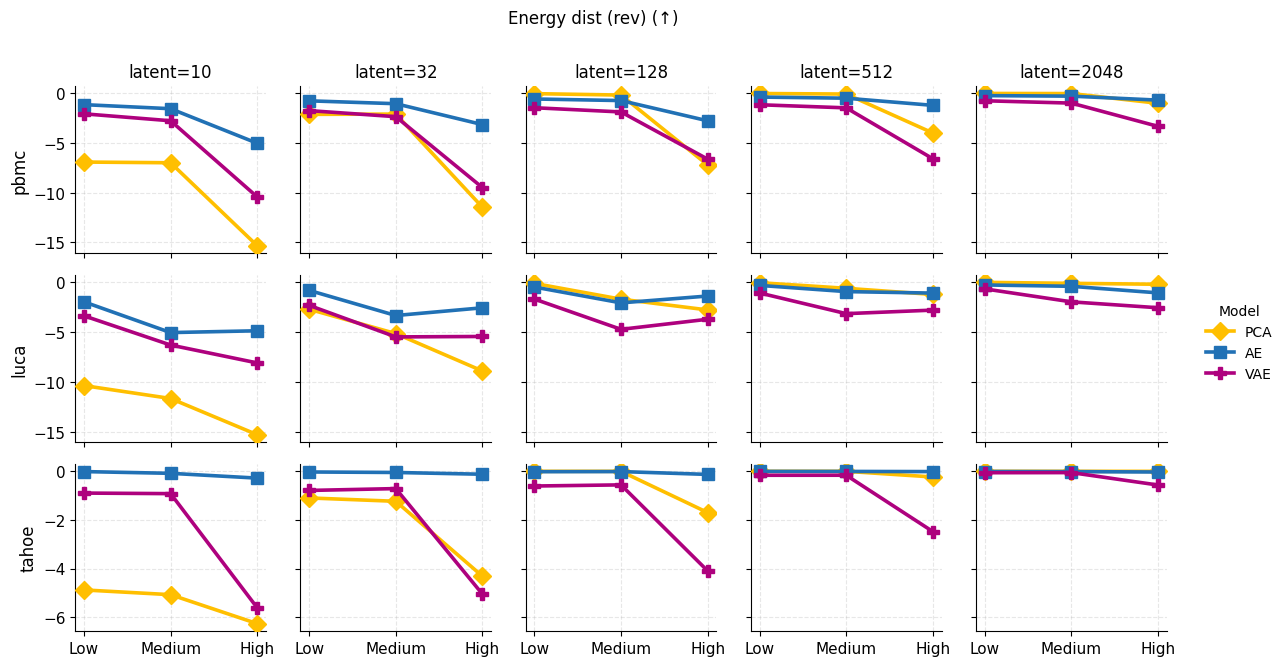

  → ../figs/fig2/scaling_split_deg_wilcoxon_pred_mean_genediff_spearman.svg


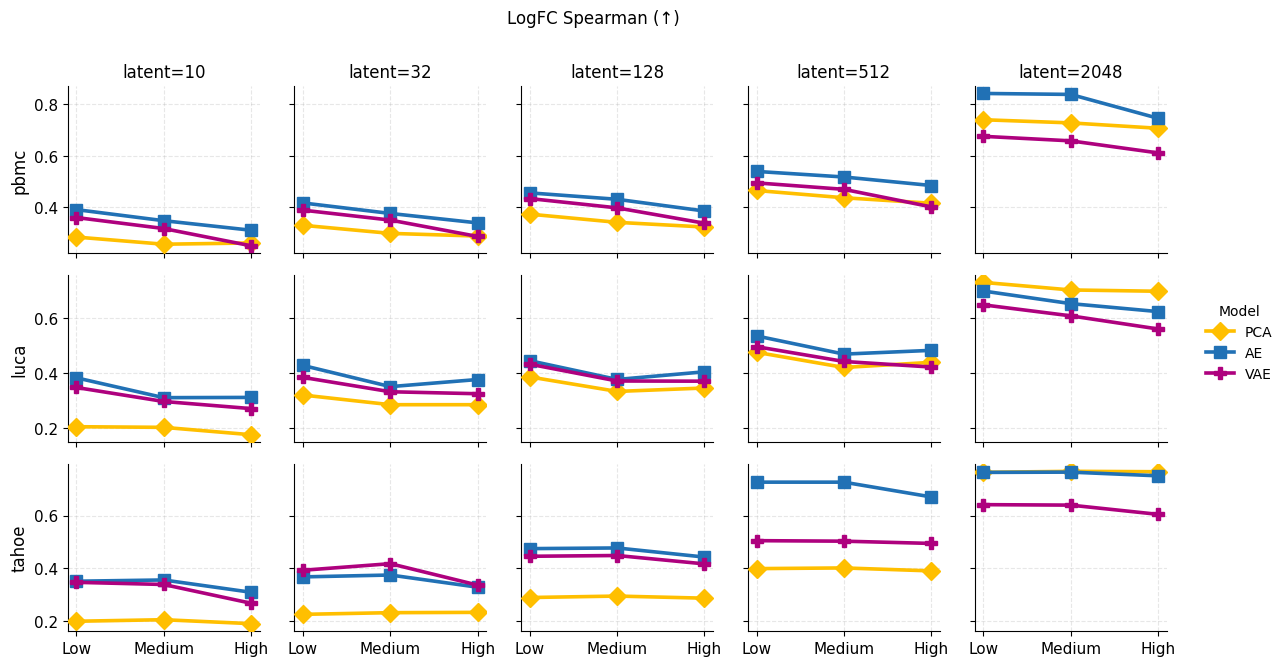

In [30]:
SPLIT_LABELS = ["Low", "Medium", "High"]
SPLITS = ["split03", "split02", "split01"]

def plot_scaling_split(long_df, metric_col, metric_label, higher_is_better, out_svg=None):
    sub = long_df[long_df["metric"] == metric_col].copy()
    no_data = sub["value"].notna().sum() == 0

    n_rows, n_cols = len(DATASETS), len(LATENTS)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 2.2 * n_rows),
                             sharex=True, sharey="row")
    if n_rows == 1: axes = np.atleast_2d(axes)

    split_x = {s: i for i, s in enumerate(SPLITS)}

    if no_data:
        for i, ds in enumerate(DATASETS):
            for j, lat in enumerate(LATENTS):
                ax = axes[i, j]
                ax.text(0.5, 0.5, "Pending", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, color="grey", style="italic")
                ax.set_xticks(list(split_x.values()))
                ax.set_xticklabels(SPLIT_LABELS)
                if i == 0: ax.set_title(f"latent={lat}")
                if j == 0: ax.set_ylabel(ds)
                for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
        fig.suptitle(metric_label + " — placeholder (running)", y=1.005, fontsize=12, color="grey")
        plt.tight_layout()
        if out_svg:
            fig.savefig(out_svg, format="svg", bbox_inches="tight")
            print(f"  → {out_svg} (placeholder)")
        plt.show()
        return fig

    for i, ds in enumerate(DATASETS):
        for j, lat in enumerate(LATENTS):
            ax = axes[i, j]
            d = sub[(sub["dataset"] == ds) & (sub["latent"] == lat)]
            for model in MODEL_ORDER:
                md = d[d["model"] == model].copy()
                if md.empty: continue
                md["x"] = md["split"].map(split_x)
                md = md.sort_values("x")
                ax.plot(md["x"], md["value"],
                        marker=MODEL_MARKER[model], ms=9, lw=2.6,
                        color=MODEL_COLOR[model], label=DISPLAY_NAMES.get(model, model), zorder=3)
            ax.set_xticks(list(split_x.values()))
            ax.set_xticklabels(SPLIT_LABELS)
            if i == 0:
                ax.set_title(f"latent={lat}")
            if j == 0:
                ax.set_ylabel(ds)
            ax.grid(True, ls="--", alpha=0.3)
            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)

    handles = [Line2D([0],[0], marker=MODEL_MARKER[m], color=MODEL_COLOR[m], lw=2.6, ms=9, label=DISPLAY_NAMES.get(m, m))
               for m in MODEL_ORDER if m in sub["model"].unique()]
    fig.legend(handles=handles, title="Model",
               loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
    fig.suptitle(metric_label + (" (↑)" if higher_is_better else " (↓)"), y=1.005, fontsize=12)
    plt.tight_layout()
    if out_svg:
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"  → {out_svg}")
    plt.show()
    return fig

for col, label, hib in METRICS:
    safe = re.sub(r"[^a-zA-Z0-9]+", "_", col)
    out = os.path.join(FIGS_DIR, f"scaling_split_{safe}.svg")
    plot_scaling_split(long_df, col, label, hib, out_svg=out)

## 4. Plot 4 — Average ranking (overall rank-percentile)

Overall rank-percentile per model, computed exactly like `fig2_summary_panel`'s overall score:
`overall = mean(statistical, biological)`, where each category is the mean rank-percentile of its
metrics. Pool = **PCA / olAE / nlscVI** only. Two panels:
- **OOD level** — x = Low/Medium/High (split03/02/01), averaged over datasets × latents
- **Dataset** — x = LuCA/PBMC/Tahoe, averaged over OOD splits × latents
Shaded band = ±1 SD across the collapsed dimensions.

  → ../figs/fig2/average_ranking.svg


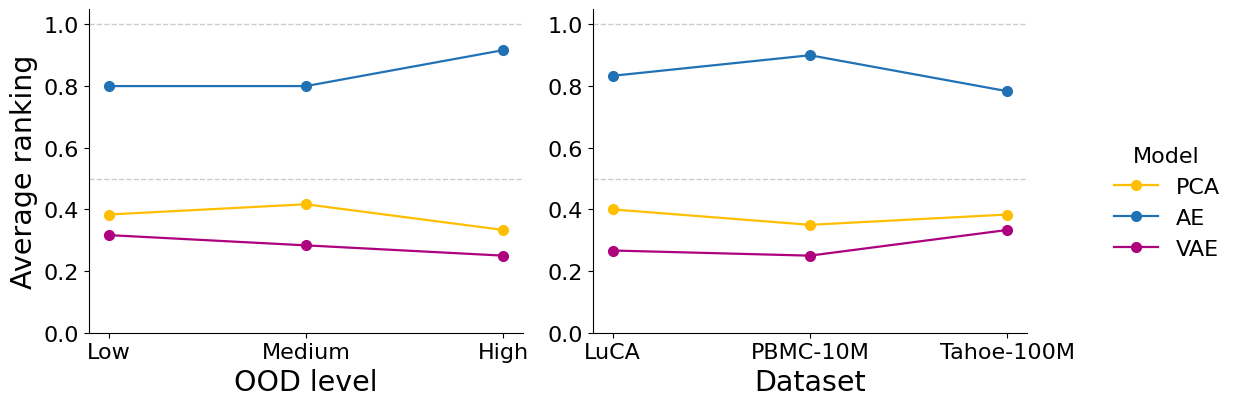

In [31]:
RANK_MODELS = ["PCA", "olAE", "nlscVI"]

STAT_COLS = {"distributional_r2_score", "rev_distributional_mse",
             "rev_distributional_mmd_rbf", "rev_distributional_energy_distance"}
BIO_COLS  = {"pathway_spearman_average", "coexpression_spearman_average",
             "cellcycle_proportion_same_phase", "deg_wilcoxon_pred_deg_dice_100",
             "deg_wilcoxon_pred_mean_genediff_spearman", "cytokine_spearman_average"}

DS_LABELS = {"pbmc": "PBMC-10M", "luca": "LuCA", "tahoe": "Tahoe-100M"}
DS_ORDER  = ["luca", "pbmc", "tahoe"]


def compute_overall_rank(long_df, models=RANK_MODELS):
    """Per (dataset, split, latent, model): overall rank-percentile = mean(stat, bio)."""
    sub = long_df[long_df["model"].isin(models)].dropna(subset=["value"]).copy()
    grp_key = ["dataset", "split", "latent", "metric"]
    ranks  = (sub.groupby(grp_key)["value"]
                 .rank(method="average", ascending=False))
    nval   = sub.groupby(grp_key)["value"].transform("count").astype(float)
    sub["rank_pct"] = np.where(nval >= 2, (nval - ranks) / (nval - 1), np.nan)
    sub["category"] = np.where(sub["metric"].isin(STAT_COLS), "stat",
                       np.where(sub["metric"].isin(BIO_COLS), "bio", "other"))
    sub = sub[sub["category"] != "other"]
    # mean rank-pct per category
    cat = (sub.groupby(["dataset", "split", "latent", "model", "category"])["rank_pct"]
              .mean().reset_index())
    wide = cat.pivot_table(index=["dataset", "split", "latent", "model"],
                           columns="category", values="rank_pct").reset_index()
    wide["overall"] = 0.5 * (wide["stat"] + wide["bio"])
    return wide


def plot_average_ranking(long_df, out_svg=None):
    wide = compute_overall_rank(long_df)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    ax = axes[0]
    x_ood = {s: i for i, s in enumerate(SPLITS)}
    for model in RANK_MODELS:
        d = wide[wide["model"] == model]
        g = d.groupby("split")["overall"].agg(["mean", "std"]).reindex(SPLITS)
        xs = [x_ood[s] for s in g.index]
        ax.plot(xs, g["mean"], marker="o", ms=7, lw=1.6,
                color=MODEL_COLOR[model], label=DISPLAY_NAMES.get(model, model), zorder=3)
    ax.set_xticks(list(x_ood.values())); ax.set_xticklabels(SPLIT_LABELS, fontsize=18)
    ax.set_xlabel("OOD level", fontsize=20.5)
    ax.set_ylabel("Average ranking", fontsize=20.5)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="0.8", ls="--", lw=1, zorder=0)
    ax.axhline(1.0, color="0.8", ls="--", lw=1, zorder=0)
    ax.tick_params(labelsize=16)
    for s in ["top", "right"]: ax.spines[s].set_visible(False)

    ax = axes[1]
    x_ds = {d: i for i, d in enumerate(DS_ORDER)}
    for model in RANK_MODELS:
        d = wide[wide["model"] == model]
        g = d.groupby("dataset")["overall"].agg(["mean", "std"]).reindex(DS_ORDER)
        xs = [x_ds[ds] for ds in g.index]
        ax.plot(xs, g["mean"], marker="o", ms=7, lw=1.6,
                color=MODEL_COLOR[model], label=DISPLAY_NAMES.get(model, model), zorder=3)
    ax.set_xticks(list(x_ds.values()))
    ax.set_xticklabels([DS_LABELS[d] for d in DS_ORDER], fontsize=18)
    ax.set_xlabel("Dataset", fontsize=20.5)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="0.8", ls="--", lw=1, zorder=0)
    ax.axhline(1.0, color="0.8", ls="--", lw=1, zorder=0)
    ax.tick_params(labelsize=16)
    for s in ["top", "right"]: ax.spines[s].set_visible(False)

    handles = [Line2D([0], [0], marker="o", color=MODEL_COLOR[m], lw=1.6, ms=7,
                      label=DISPLAY_NAMES.get(m, m)) for m in RANK_MODELS]
    fig.legend(handles=handles, title="Model", loc="center left",
               bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=16, title_fontsize=16)
    plt.tight_layout()
    if out_svg:
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"  → {out_svg}")
    plt.show()


plot_average_ranking(long_df, out_svg=os.path.join(FIGS_DIR, "average_ranking.svg"))

## 5. Plot 3 — Decoder-only OOD (MLP)

Decoder-only reconstruction (foundation-model embedding → MLP decoder → gene space). For each metric, plot value vs split with one line per foundation model. Mirrors the OOD view of Plot 2 but for the decoder-only setting.

Per-seed mean is taken before averaging.

In [32]:
FM_ORDER  = ["scConcept", "scGPT", "scimilarity", "SE"]
FM_COLORS = {"scConcept": "#6a3d9a", "scGPT": "#d94801",
             "scimilarity": "#1f9d8a", "SE": "#08519c"}
FM_MARKERS = {"scConcept": "o", "scGPT": "s", "scimilarity": "^", "SE": "D"}
FM_LABELS  = {"scConcept": "scConcept", "scGPT": "scGPT", "scimilarity": "SCimilarity", "SE": "SE"}

DEC_SPLITS  = ["split03", "split02", "split01"]
DEC_LABELS  = ["Low", "Medium", "High"]

DEC_METRICS = [
    ("rev_distributional_energy_distance", "-Energy distance (rev)",  True),
    ("deg_pred_mean_genediff_spearman",    "Mean gene-diff Spearman", True),
]

dec_long = pd.read_csv("../frozen/figs/decoder_only_long.csv")

  → ../figs/fig2/decoder_mlp_split_rev_distributional_energy_distance.svg


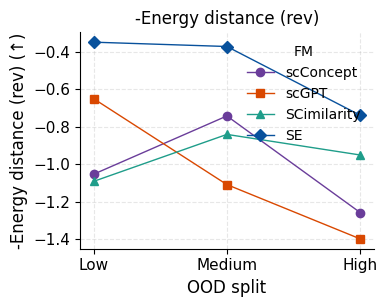

  → ../figs/fig2/decoder_mlp_split_deg_pred_mean_genediff_spearman.svg


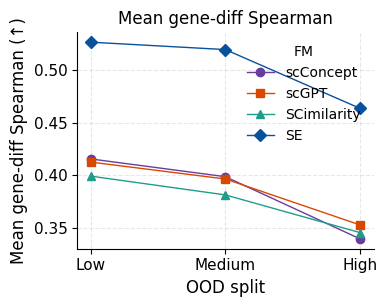

In [33]:
def plot_decoder_split(dec_long, metric_col, metric_label, higher_is_better, out_svg=None):
    sub = dec_long[dec_long["metric"] == metric_col].copy()

    fig, ax = plt.subplots(figsize=(4.0, 3.2))

    if sub["value"].notna().sum() == 0:
        ax.text(0.5, 0.5, "Pending", ha="center", va="center",
                transform=ax.transAxes, fontsize=11, color="grey", style="italic")
        ax.set_xticks(range(len(DEC_SPLITS)))
        ax.set_xticklabels(DEC_LABELS)
        ax.set_xlabel("OOD split")
        ax.set_ylabel(metric_label + (" (↑)" if higher_is_better else " (↓)"))
        ax.set_title(f"{metric_label} — MLP decoder")
        for s in ["top", "right"]:
            ax.spines[s].set_visible(False)
        plt.tight_layout()
        if out_svg:
            fig.savefig(out_svg, format="svg", bbox_inches="tight")
            print(f"  → {out_svg} (placeholder)")
        plt.show()
        return fig

    # mean across seeds per (fm, split)
    agg = (sub.dropna(subset=["value"])
              .groupby(["fm", "split"])["value"].mean().reset_index())
    split_x = {s: i for i, s in enumerate(DEC_SPLITS)}

    for fm in FM_ORDER:
        d = agg[agg["fm"] == fm].copy()
        if d.empty:
            continue
        d["x"] = d["split"].map(split_x)
        d = d.sort_values("x")
        ax.plot(d["x"], d["value"],
                marker=FM_MARKERS[fm], ms=6, lw=1.0,
                color=FM_COLORS[fm], label=FM_LABELS.get(fm, fm), zorder=3)

    ax.set_xticks(list(split_x.values()))
    ax.set_xticklabels(DEC_LABELS)
    ax.set_xlabel("OOD split")
    ax.set_ylabel(metric_label + (" (↑)" if higher_is_better else " (↓)"))
    ax.set_title(f"{metric_label}")
    ax.grid(True, ls="--", alpha=0.3)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

    handles = [Line2D([0], [0], marker=FM_MARKERS[fm], color=FM_COLORS[fm],
                       lw=1.0, ms=6, label=FM_LABELS.get(fm, fm))
               for fm in FM_ORDER if fm in sub["fm"].unique()]
    ax.legend(handles=handles, title="FM", loc="best", frameon=False)

    plt.tight_layout()
    if out_svg:
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"  → {out_svg}")
    plt.show()
    return fig


for col, label, hib in DEC_METRICS:
    safe = re.sub(r"[^a-zA-Z0-9]+", "_", col)
    out = os.path.join(FIGS_DIR, f"decoder_mlp_split_{safe}.svg")
    plot_decoder_split(dec_long, col, label, hib, out_svg=out)